# Fair Lending Project - Seattle University

Data Preparation - SBA-Kaggle

Build Final Modeling Dataset across SBA-Kaggle, Census Annual Business Survey (ABS) And FRED Economic Data 

In [8]:
import pandas as pd
import numpy as np
import sqlite3
import os
import requests
import matplotlib.pyplot as plt


## Prep Environment

In [3]:
sba_loan_path = '../data/raw/SBAnational.csv'
sba_project_db_path = '../data/sba_loans.db'
sba_loan_ulr = 'https://www.dropbox.com/scl/fi/mviwrww37tjwmhhnqzqyd/SBAnational.csv?rlkey=mofv5v8wvnrv4feryeo9e3k59&st=555796oo&dl=1'

#Cache data locally if not already present
if not os.path.exists(sba_loan_path):
    print("Downloading SBA loan data ...")
    response = requests.get(sba_loan_url)
    response.raise_for_status()
    with open(sba_loan_path, 'wb') as f:
        f.write(response.content)
    print("Downloaded SBA loan data.")
else:
    print("SBA loan data already exists.")

SBA loan data already exists.


## Load Data and Clean SBA Data

In [21]:
df_sba = pd.read_csv(sba_loan_path, low_memory=False)
print(f"Raw: {df_sba.shape[0]:,} rows × {df_sba.shape[1]} columns")

Raw: 899,164 rows × 27 columns


In [6]:
# ============================================================
# STEP 2: Clean SBA Loan Data
# ============================================================
df_sba = pd.read_csv(sba_loan_path, low_memory=False)
print(f"Raw: {df_sba.shape[0]:,} rows × {df_sba.shape[1]} columns")

# 1. Drop missing target & create binary
df_sba = df_sba[df_sba['MIS_Status'].notna()].copy()
df_sba['MIS_Status'] = df_sba['MIS_Status'].str.strip()
df_sba = df_sba[df_sba['MIS_Status'].isin(['P I F', 'CHGOFF'])]
df_sba['is_default'] = (df_sba['MIS_Status'] == 'CHGOFF').astype(int)

# 2. Filter to 1987+
df_sba['ApprovalFY'] = pd.to_numeric(df_sba['ApprovalFY'], errors='coerce')
df_sba = df_sba[df_sba['ApprovalFY'] >= 1987]

# 3. Clean currency columns
for col in ['DisbursementGross', 'BalanceGross', 'ChgOffPrinGr', 'GrAppv', 'SBA_Appv']:
    df_sba[col] = df_sba[col].astype(str).str.replace(r'[\$,]', '', regex=True)
    df_sba[col] = pd.to_numeric(df_sba[col], errors='coerce')

# 4. Extract 2-digit NAICS
df_sba['naics_2digit'] = df_sba['NAICS'].astype(str).str[:2]

# 5. Rename state for join consistency
df_sba = df_sba.rename(columns={'State': 'state'})

# 6. Clean categoricals
df_sba['RevLineCr'] = df_sba['RevLineCr'].where(df_sba['RevLineCr'].isin(['Y','N']), np.nan)
df_sba['LowDoc'] = df_sba['LowDoc'].where(df_sba['LowDoc'].isin(['Y','N']), np.nan)
df_sba['NewExist'] = df_sba['NewExist'].replace(0, np.nan)

print(f"Cleaned: {df_sba.shape[0]:,} rows × {df_sba.shape[1]} columns")
print(f"Default rate: {df_sba['is_default'].mean():.3f}")
print(f"Year range: {int(df_sba['ApprovalFY'].min())}–{int(df_sba['ApprovalFY'].max())}")
print(f"States: {df_sba['state'].nunique()}")
print(f"NAICS sectors: {sorted(df_sba['naics_2digit'].unique())}")

Raw: 899,164 rows × 27 columns
Cleaned: 886,649 rows × 29 columns
Default rate: 0.172
Year range: 1987–2014
States: 51
NAICS sectors: ['0', '11', '21', '22', '23', '31', '32', '33', '42', '44', '45', '48', '49', '51', '52', '53', '54', '55', '56', '61', '62', '71', '72', '81', '92']


## Define SBA SQL Schema and Load Data

In [23]:
# ============================================================
# STEP 4: Create SQLite Database with Schema
# ============================================================
conn = sqlite3.connect(sba_project_db_path)
cursor = conn.cursor()

# Enable foreign keys
cursor.execute("PRAGMA foreign_keys = ON;")

# Table 1: industry_sector (lookup table)
cursor.execute('''
CREATE TABLE IF NOT EXISTS industry_sector (
    naics_2digit TEXT PRIMARY KEY,
    sector_name TEXT NOT NULL
)
''')


# Table 4: loan
cursor.execute('''
CREATE TABLE IF NOT EXISTS loan (
    loan_id TEXT PRIMARY KEY,
    naics_2digit TEXT,
    state TEXT,
    approval_year INTEGER,
    term INTEGER,
    no_emp INTEGER,
    new_exist REAL,
    urban_rural INTEGER,
    rev_line_cr TEXT,
    low_doc TEXT,
    gross_approved REAL,
    sba_approved REAL,
    disbursement_gross REAL,
    is_default INTEGER NOT NULL,
    FOREIGN KEY (naics_2digit) REFERENCES industry_sector(naics_2digit),
    FOREIGN KEY (approval_year) REFERENCES economic_indicator(data_year)
)
''')

conn.commit()
print("Schema created successfully!")
print("\nTables:")
for row in cursor.execute("SELECT name FROM sqlite_master WHERE type='table'").fetchall():
    print(f"  {row[0]}")

Schema created successfully!

Tables:
  industry_sector
  loan


In [ ]:
# ============================================================
# STEP 5: Load Data into SQLite
# ============================================================

# --- 5a: Industry Sector lookup ---
naics_names = {
    '11': 'Agriculture', '21': 'Mining', '22': 'Utilities',
    '23': 'Construction', '31': 'Manufacturing', '32': 'Manufacturing',
    '33': 'Manufacturing', '42': 'Wholesale Trade', '44': 'Retail Trade',
    '45': 'Retail Trade', '48': 'Transportation', '49': 'Transportation',
    '51': 'Information', '52': 'Finance/Insurance',
    '53': 'Real Estate', '54': 'Professional Services',
    '55': 'Management', '56': 'Administrative Services',
    '61': 'Education', '62': 'Healthcare', '71': 'Arts/Entertainment',
    '72': 'Accommodation/Food', '81': 'Other Services',
    '92': 'Public Administration', '99': 'Unclassified'
}

conn = sqlite3.connect(sba_project_db_path)
cursor = conn.cursor()

df_sectors = pd.DataFrame(list(naics_names.items()), columns=['naics_2digit', 'sector_name'])
df_sectors.to_sql('industry_sector', conn, if_exists='replace', index=False)
print(f"industry_sector: {len(df_sectors)} rows loaded")

# --- 5d: Loan table ---
df_loan = df_sba[['LoanNr_ChkDgt', 'naics_2digit', 'state', 'ApprovalFY',
                   'Term', 'NoEmp', 'NewExist', 'UrbanRural',
                   'RevLineCr', 'LowDoc', 'GrAppv', 'SBA_Appv',
                   'DisbursementGross', 'is_default']].copy()

df_loan.columns = ['loan_id', 'naics_2digit', 'state', 'approval_year',
                    'term', 'no_emp', 'new_exist', 'urban_rural',
                    'rev_line_cr', 'low_doc', 'gross_approved', 'sba_approved',
                    'disbursement_gross', 'is_default']

df_loan['approval_year'] = df_loan['approval_year'].astype(int)
df_loan.to_sql('loan', conn, if_exists='replace', index=False)
print(f"loan: {len(df_loan):,} rows loaded")

conn.commit()
conn.close()
print("\nAll tables loaded!")

industry_sector: 25 rows loaded
loan: 886,649 rows loaded

All tables loaded!


## Define SBA View with Sector Mapped to Census

In [17]:
# ============================================================
# Create View with NAICS mapped to Census Sector Ranges
# ============================================================
view_sql = '''
DROP VIEW IF EXISTS V_SBA_LOAN;

CREATE VIEW V_SBA_LOAN AS
SELECT
    loan_id,
    naics_2digit,
    state,
    approval_year,
    term,
    no_emp,
    new_exist,
    urban_rural,
    rev_line_cr,
    low_doc,
    gross_approved,
    sba_approved,
    disbursement_gross,
    is_default,
    CASE -- map NAICS 2-digit to Census sector ranges
        WHEN naics_2digit = '0' THEN '99' -- Unclassified
        WHEN naics_2digit IN ('31', '32', '33') THEN '31-33'
        WHEN naics_2digit IN ('44', '45') THEN '44-45'
        WHEN naics_2digit IN ('48', '49') THEN '48-49'
        ELSE naics_2digit
    END AS sector_text
FROM loan;
'''
conn = sqlite3.connect(sba_project_db_path)
cursor = conn.cursor()

cursor.executescript(view_sql)
conn.commit()
conn.close()
print("View 'V_SBA_LOAN' created successfully!")

View 'V_SBA_LOAN' created successfully!


In [31]:

# Connect to your database
conn = sqlite3.connect(sba_project_db_path)

df_sector = pd.read_sql_query("SELECT * FROM V_SBA_LOAN", conn)
conn.close()

df_sector.head()



,loan_id,naics_2digit,state,approval_year,term,no_emp,new_exist,urban_rural,rev_line_cr,low_doc,gross_approved,sba_approved,disbursement_gross,is_default,sector_text
0,1000014003,45,IN,1997,84,4,2.0,0,N,Y,60000.0,48000.0,60000.0,0,44-45
1,1000024006,72,IN,1997,60,2,2.0,0,N,Y,40000.0,32000.0,40000.0,0,72
2,1000034009,62,IN,1997,180,7,1.0,0,N,N,287000.0,215250.0,287000.0,0,62
3,1000044001,0,OK,1997,60,2,1.0,0,N,Y,35000.0,28000.0,35000.0,0,99
4,1000054004,0,FL,1997,240,14,1.0,0,N,N,229000.0,229000.0,229000.0,0,99


In [30]:
df_sector.describe()


,loan_id,approval_year,term,no_emp,new_exist,urban_rural,gross_approved,sba_approved,disbursement_gross,is_default
count,8.866490e+05,886649.000000,886649.000000,886649.000000,885505.000000,886649.000000,8.866490e+05,8.866490e+05,8.866490e+05,886649.000000
mean,4.800955e+09,2001.351242,110.093821,11.224500,1.282059,0.766257,1.929663e+05,1.493405e+05,2.016339e+05,0.172033
std,2.533611e+09,5.609874,78.443072,73.059293,0.450002,0.645050,2.846444e+05,2.294018e+05,2.890607e+05,0.377409
min,1.000014e+09,1987.000000,0.000000,0.000000,1.000000,0.000000,1.000000e+03,5.000000e+02,4.000000e+03,0.000000
25%,2.632785e+09,1997.000000,60.000000,2.000000,1.000000,0.000000,3.500000e+04,2.125000e+04,4.192700e+04,0.000000
50%,4.401324e+09,2003.000000,84.000000,4.000000,1.000000,1.000000,9.000000e+04,6.000000e+04,1.000000e+05,0.000000
75%,6.942864e+09,2006.000000,120.000000,10.000000,2.000000,1.000000,2.250000e+05,1.736000e+05,2.374020e+05,0.000000
max,9.996003e+09,2014.000000,569.000000,9999.000000,2.000000,2.000000,5.472000e+06,5.472000e+06,1.144632e+07,1.000000


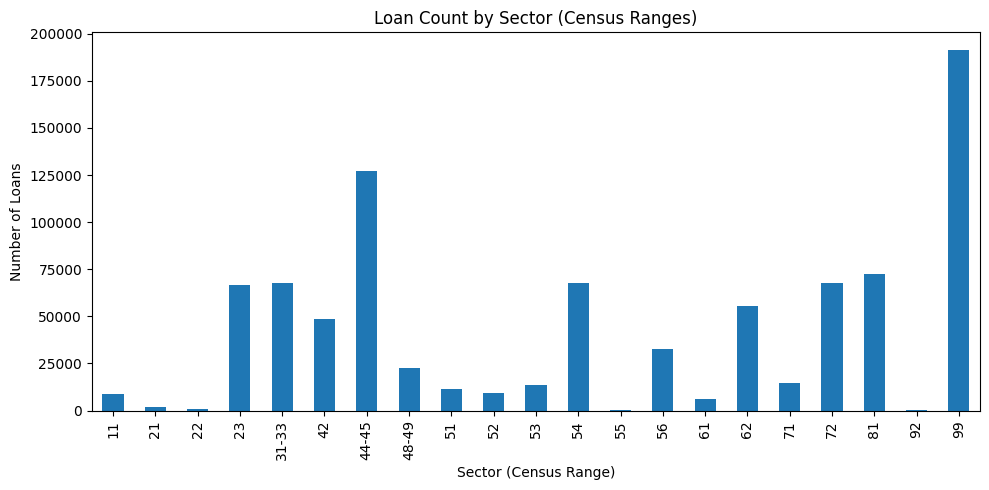

In [20]:
plt.figure(figsize=(10, 5))
df_sector['sector_text'].value_counts().sort_index().plot(kind='bar')
plt.title('Loan Count by Sector (Census Ranges)')
plt.xlabel('Sector (Census Range)')
plt.ylabel('Number of Loans')
plt.tight_layout()
plt.show()


Significant number of unclassified sectors, which would impact our industry-state segments evaluation. We will need to update view to use state average for unclassified instead.
